# 📊 DNS Bayesiano con Gibbs Sampler
## Forward Filter Backward Sampler (FFBS) + Posteriors Conjugadas + MH para λ

### Fundamento teórico

El DNS bayesiano resuelve el problema central que tiene el Kalman Filter con MLE:

| Aspecto | Kalman Filter (MLE) | Gibbs Sampler (Bayes) |
|---------|--------------------|-----------------------|
| Factores β₁:T | Estimado puntual E[βt\|Y,θ̂] | Distribución completa p(β₁:T\|Y) |
| Parámetros θ | Optimización numérica | Distribución posterior p(θ\|Y) |
| Incertidumbre | Solo la del estado (Pt\|t) | Paramétrica + de estado |
| Intervalos | Basados en KF lineal | Intervalos de credibilidad exactos |
| τ | Fijo o grid search | Distribución posterior vía MH |

### Modelo estado-espacio

**Observación:** $\mathbf{y}_t = \mathbf{H}(\tau_1,\tau_2)\boldsymbol{\beta}_t + \boldsymbol{\varepsilon}_t, \quad \boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{R})$

**Transición (F diagonal — Caldeira P7):** $\boldsymbol{\beta}_t = \boldsymbol{\mu} + \mathbf{F}(\boldsymbol{\beta}_{t-1} - \boldsymbol{\mu}) + \boldsymbol{\eta}_t, \quad \boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{Q})$

### Algoritmo FFBS (Carter & Kohn 1994)

```
Forward:  Kalman filter → guarda (β̂t|t, Pt|t) para todo t
Backward: βT ~ N(β̂T|T, PT|T)
          para t = T-1,...,1:
            Gt = Pt|t F' Pt+1|t⁻¹           ← ganancia suavizadora
            βt|βt+1,Y ~ N(μt|T, Σt|T)        ← muestra directa
```

### ¿Por qué F diagonal?
Caldeira et al. (2010) comparan P6 (VAR completo) vs P7 (diagonal): diferencia de RMSE < 0.4pb. Çakmaklı (2013) restringe explícitamente los off-diagonals a cero. Los factores DNS ya capturan variación ortogonal entre sí — los off-diagonals añaden 6 parámetros sin mejora significativa.

### Referencias
- Caldeira, Laurini & Portugal (2010) — *Brazilian Review of Econometrics* 30(1)
- Çakmaklı (2013) — *Bayesian Semiparametric DNS*
- Carter & Kohn (1994) — *Biometrika* 81(3)


## CELDA 0: Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import invgamma, truncnorm
from scipy.stats import jarque_bera
from joblib import Parallel, delayed
import warnings, time
warnings.filterwarnings('ignore')

try:
    from numba import njit
    _NUMBA = True
    print("✓ Numba disponible — FFBS JIT activado")
except ImportError:
    _NUMBA = False
    print("⚠ Numba no disponible — modo Python puro")

np.random.seed(42)

✓ Numba disponible — FFBS JIT activado


## CELDA 1: Carga de datos

In [3]:
rend_EEUU = pd.read_csv("C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\Datos\\rendimiento_tesoro_EEUU.csv")
    
yield_cols = ["SVENY01","SVENY02","SVENY03","SVENY05",
              "SVENY07","SVENY10","SVENY20","SVENY30"]
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

df = rend_EEUU[["Date"] + yield_cols].copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna(subset=yield_cols).sort_values("Date").reset_index(drop=True)
df = df[::10]   # frecuencia semanal

yields_data = df[yield_cols].values
dates       = df["Date"].values
T, N        = yields_data.shape

print(f"Observaciones: {T} | Plazos: {N}")
print(f"Rango: {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")

Observaciones: 1006 | Plazos: 8
Rango: 1985-11-25 → 2026-03-03


## CELDA 2: NSS loadings + búsqueda inicial de τ

In [4]:
def nss_loadings(maturities: np.ndarray, tau1: float, tau2: float) -> np.ndarray:
    """
    Cargas H del modelo Nelson-Siegel-Svensson. Shape (N, 4).
    Columnas: [β₀ nivel, β₁ pendiente, β₂ curvatura1, β₃ curvatura2]
    Hump de β₂ en m ≈ 1.793·τ₁ años; hump de β₃ en m ≈ 1.793·τ₂ años.
    """
    m   = np.asarray(maturities, dtype=float)
    mt1 = m / tau1;  mt2 = m / tau2
    e1  = np.exp(-mt1);  e2 = np.exp(-mt2)
    c1  = (1.0 - e1) / mt1
    return np.column_stack([np.ones_like(m), c1, c1 - e1, (1.0 - e2)/mt2 - e2])


def profile_sse(tau1: float, tau2: float) -> float:
    """SSE del OLS two-step. Usado para inicializar τ antes del MCMC."""
    if abs(tau1 - tau2) < 0.15:
        return np.inf
    H = nss_loadings(maturities, tau1, tau2)
    try:
        B = np.linalg.lstsq(H, yields_data.T, rcond=None)[0]
    except Exception:
        return np.inf
    return float(np.sum((yields_data.T - H @ B)**2))


tau1_grid = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0])
tau2_grid = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0])

sse_best = np.inf
TAU1_INIT = 1.5;  TAU2_INIT = 0.5
for t1 in tau1_grid:
    for t2 in tau2_grid:
        s = profile_sse(t1, t2)
        if s < sse_best:
            sse_best = s;  TAU1_INIT = t1;  TAU2_INIT = t2

print(f"τ inicial óptimo (grid OLS): τ₁={TAU1_INIT:.2f}  τ₂={TAU2_INIT:.2f}")
print(f"  → hump β₂ en ~{1.793*TAU1_INIT:.2f}Y  |  hump β₃ en ~{1.793*TAU2_INIT:.2f}Y")

τ inicial óptimo (grid OLS): τ₁=3.00  τ₂=0.40
  → hump β₂ en ~5.38Y  |  hump β₃ en ~0.72Y


## Forward Filter Backward Sampler (FFBS) — Implementación JIT

El FFBS es el bloque más crítico del Gibbs sampler: muestrea β₁:T completo en una sola pasada, en lugar de muestrear cada βt individualmente (lo que causa alta autocorrelación). Compilado con Numba para máxima velocidad.


In [5]:
#
# La innovación clave respecto al enfoque MLE/KF:
#
#   KF (MLE):   estima E[βt | Y1:T] como un punto → intervalos incorrectos
#   FFBS:       muestrea de p(β1:T | Y, θ) exactamente → distribución completa
#
# Algoritmo (Carter & Kohn 1994):
#   Forward:  Kalman filter estándar → guarda (βt|t, Pt|t) para todo t
#   Backward: muestrea βT ~ N(βT|T, PT|T), luego para t=T-1,...,1:
#             βt | βt+1, Y ~ N(μt|T, Σt|T) donde:
#               μt|T = βt|t + Gt(βt+1 - μ - F(βt|t - μ))
#               Σt|T = Pt|t - Gt Pt+1|t Gt'
#               Gt   = Pt|t F' Pt+1|t^{-1}   (ganancia suavizadora)
#               Pt+1|t = F Pt|t F' + Q
if _NUMBA:
    @njit(cache=True)
    def ffbs(mu, f_vec, q_vec, r_vec, H, yields):
        """
        Forward Filter Backward Sampler compilado con Numba.
        F diagonal → operaciones explícitas por elemento.
        Retorna: betas (T, 4) — una trayectoria muestreada de la posterior.
        """
        T_obs, N_obs = yields.shape
        n = 4

        # Almacenamiento del filtro forward
        beta_filt = np.zeros((T_obs, n))
        P_filt    = np.zeros((T_obs, n, n))

        # Inicialización estacionaria
        beta_hat = mu.copy()
        P = np.zeros((n, n))
        for i in range(n):
            P[i, i] = q_vec[i] / (1.0 - f_vec[i]**2)

        In = np.eye(n)

        # ── FORWARD: Kalman Filter ────────────────────────────────────────────
        for t in range(T_obs):
            # Predicción: β_{t|t-1} = μ + F(β_{t-1|t-1} - μ)
            beta_pred = np.zeros(n)
            for i in range(n):
                beta_pred[i] = mu[i] + f_vec[i] * (beta_hat[i] - mu[i])

            # P_{t|t-1} = F P_{t-1|t-1} F' + Q  (F diagonal)
            P_pred = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    P_pred[i, j] = f_vec[i] * P[i, j] * f_vec[j]
            for i in range(n):
                P_pred[i, i] += q_vec[i]
            P_pred = 0.5 * (P_pred + P_pred.T)

            # Actualización
            innov = yields[t] - H @ beta_pred
            HP    = H @ P_pred
            S     = HP @ H.T
            for i in range(N_obs):
                S[i, i] += r_vec[i]
            S = 0.5 * (S + S.T)

            # Ganancia de Kalman: K = P H' S^{-1}
            K = np.linalg.solve(S, HP).T   # (n, N)

            beta_hat = beta_pred + K @ innov

            # Forma Joseph (numéricamente estable)
            IKH   = In - K @ H
            R_mat = np.zeros((N_obs, N_obs))
            for i in range(N_obs):
                R_mat[i, i] = r_vec[i]
            P = IKH @ P_pred @ IKH.T + K @ R_mat @ K.T
            P = 0.5 * (P + P.T)

            beta_filt[t] = beta_hat
            P_filt[t]    = P.copy()

        # ── BACKWARD: Simulación hacia atrás ─────────────────────────────────
        betas = np.zeros((T_obs, n))

        # Muestra βT ~ N(βT|T, PT|T)
        PT = P_filt[T_obs - 1] + 1e-10 * In
        L  = np.linalg.cholesky(PT)
        betas[T_obs - 1] = beta_filt[T_obs - 1] + L @ np.random.randn(n)

        for t in range(T_obs - 2, -1, -1):
            Pt  = P_filt[t]
            bft = beta_filt[t]

            # P_{t+1|t} = F Pt F' + Q
            Pt1_pred = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    Pt1_pred[i, j] = f_vec[i] * Pt[i, j] * f_vec[j]
            for i in range(n):
                Pt1_pred[i, i] += q_vec[i]
            Pt1_pred = 0.5 * (Pt1_pred + Pt1_pred.T)

            # Ganancia suavizadora: Gt = Pt F' Pt+1|t^{-1}
            # Con F diagonal: (Pt F')_{ij} = Pt_{ij} * f_j
            PtFT = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    PtFT[i, j] = Pt[i, j] * f_vec[j]
            Gt = np.linalg.solve(Pt1_pred.T, PtFT.T).T   # (n, n)

            # Media condicional: βt|t + Gt(βt+1 - (μ + F(βt|t - μ)))
            bt1_pred = np.zeros(n)
            for i in range(n):
                bt1_pred[i] = mu[i] + f_vec[i] * (bft[i] - mu[i])

            mu_smooth = bft + Gt @ (betas[t + 1] - bt1_pred)

            # Covarianza condicional: Pt|t - Gt Pt+1|t Gt'
            P_smooth = Pt - Gt @ Pt1_pred @ Gt.T
            P_smooth = 0.5 * (P_smooth + P_smooth.T) + 1e-10 * In

            L = np.linalg.cholesky(P_smooth)
            betas[t] = mu_smooth + L @ np.random.randn(n)

        return betas

    @njit(cache=True)
    def kalman_loglik_mh(mu, f_vec, q_vec, r_vec, H, yields):
        """
        Log-verosimilitud marginal p(Y|θ) via filtro de Kalman.
        Usada en el paso MH para evaluar la propuesta de (τ₁,τ₂).
        """
        T_obs, N_obs = yields.shape
        n = 4

        beta_hat = mu.copy()
        P = np.zeros((n, n))
        for i in range(n):
            P[i, i] = q_vec[i] / (1.0 - f_vec[i]**2)

        In      = np.eye(n)
        LOG2PI  = np.log(2.0 * np.pi)
        log_lik = 0.0

        for t in range(T_obs):
            beta_pred = np.zeros(n)
            for i in range(n):
                beta_pred[i] = mu[i] + f_vec[i] * (beta_hat[i] - mu[i])

            P_pred = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    P_pred[i, j] = f_vec[i] * P[i, j] * f_vec[j]
            for i in range(n):
                P_pred[i, i] += q_vec[i]
            P_pred = 0.5 * (P_pred + P_pred.T)

            innov = yields[t] - H @ beta_pred
            HP    = H @ P_pred
            S     = HP @ H.T
            for i in range(N_obs):
                S[i, i] += r_vec[i]
            S = 0.5 * (S + S.T)

            L_chol = np.linalg.cholesky(S)
            log_det = 0.0
            for i in range(N_obs):
                log_det += np.log(L_chol[i, i])
            log_det *= 2.0

            S_inv_nu = np.linalg.solve(S, innov)
            log_lik += -0.5 * (N_obs * LOG2PI + log_det + innov @ S_inv_nu)

            K        = np.linalg.solve(S, HP).T
            beta_hat = beta_pred + K @ innov
            IKH      = In - K @ H
            R_mat    = np.zeros((N_obs, N_obs))
            for i in range(N_obs):
                R_mat[i, i] = r_vec[i]
            P = IKH @ P_pred @ IKH.T + K @ R_mat @ K.T
            P = 0.5 * (P + P.T)

        return log_lik

else:
    # Fallback Python puro (sin Numba)
    from scipy.linalg import cho_factor, cho_solve

    def ffbs(mu, f_vec, q_vec, r_vec, H, yields):
        T_obs, N_obs = yields.shape
        n = 4
        F_mat = np.diag(f_vec)
        Q_mat = np.diag(q_vec)
        R_mat = np.diag(r_vec)
        beta_filt = np.zeros((T_obs, n))
        P_filt    = np.zeros((T_obs, n, n))
        beta_hat  = mu.copy()
        P = np.diag(q_vec / (1.0 - f_vec**2))
        In = np.eye(n)
        for t in range(T_obs):
            bp = mu + F_mat @ (beta_hat - mu)
            Pp = F_mat @ P @ F_mat.T + Q_mat; Pp = 0.5*(Pp+Pp.T)
            innov = yields[t] - H @ bp
            HP = H @ Pp; S = HP @ H.T + R_mat; S = 0.5*(S+S.T)
            K = np.linalg.solve(S, HP).T
            beta_hat = bp + K @ innov
            IKH = In - K @ H
            P = IKH @ Pp @ IKH.T + K @ R_mat @ K.T; P = 0.5*(P+P.T)
            beta_filt[t] = beta_hat; P_filt[t] = P.copy()
        betas = np.zeros((T_obs, n))
        betas[T_obs-1] = np.random.multivariate_normal(beta_filt[T_obs-1], P_filt[T_obs-1])
        for t in range(T_obs-2, -1, -1):
            Pt = P_filt[t]; bft = beta_filt[t]
            Pt1 = F_mat @ Pt @ F_mat.T + Q_mat; Pt1 = 0.5*(Pt1+Pt1.T)
            Gt = Pt @ F_mat.T @ np.linalg.inv(Pt1)
            bt1 = mu + F_mat @ (bft - mu)
            ms = bft + Gt @ (betas[t+1] - bt1)
            Ps = Pt - Gt @ Pt1 @ Gt.T; Ps = 0.5*(Ps+Ps.T) + 1e-10*In
            betas[t] = np.random.multivariate_normal(ms, Ps)
        return betas

    def kalman_loglik_mh(mu, f_vec, q_vec, r_vec, H, yields):
        T_obs, N_obs = yields.shape
        n = 4
        F_mat = np.diag(f_vec); Q_mat = np.diag(q_vec); R_mat = np.diag(r_vec)
        beta_hat = mu.copy(); P = np.diag(q_vec/(1.0-f_vec**2))
        In = np.eye(n); log_lik = 0.0
        for t in range(T_obs):
            bp = mu + F_mat@(beta_hat-mu); Pp = F_mat@P@F_mat.T+Q_mat; Pp=0.5*(Pp+Pp.T)
            innov=yields[t]-H@bp; HP=H@Pp; S=HP@H.T+R_mat; S=0.5*(S+S.T)
            c,low = cho_factor(S,lower=True,check_finite=False)
            ld = 2*np.sum(np.log(np.diag(c)))
            nu = cho_solve((c,low),innov,check_finite=False)
            log_lik += -0.5*(N_obs*np.log(2*np.pi)+ld+innov@nu)
            K=cho_solve((c,low),HP,check_finite=False).T
            beta_hat=bp+K@innov; IKH=In-K@H
            P=IKH@Pp@IKH.T+K@R_mat@K.T; P=0.5*(P+P.T)
        return log_lik

## CELDA 4: Warm-up JIT

In [6]:
if _NUMBA:
    print("Compilando FFBS + loglik JIT...", end=" ")
    _d = np.random.randn(15, N)*0.05 + 4.0
    _m = np.ones(4)*4; _f = np.ones(4)*0.9; _q = np.ones(4)*0.01; _r = np.ones(N)*0.001
    _H = nss_loadings(maturities, 1.5, 0.5)
    ffbs(_m, _f, _q, _r, _H, _d)
    kalman_loglik_mh(_m, _f, _q, _r, _H, _d)
    print("listo ✓")

Compilando FFBS + loglik JIT... listo ✓


## Posteriors Conjugadas para F, μ, Q, R

Los bloques conjugados tienen tasa de aceptación 100% — no requieren MH. Cada distribución condicional es exactamente Normal o Inverse-Gamma, muestreada directamente.


In [7]:
#
# DERIVACIÓN DE LAS POSTERIORS CONJUGADAS
# El modelo de estado (factor i, F diagonal) es:
#   βi,t = μi + fi*(βi,t-1 - μi) + ηi,t,   ηi,t ~ N(0, qi)
#
# Re-parametrizando con demeaned ai,t = βi,t - μi:
#   ai,t = fi * ai,t-1 + ηi,t   (AR(1) puro)
#
# Para μi dado fi:
#   βi,t - fi*βi,t-1 = (1-fi)*μi + ηi,t   → Normal conjugada
#   Prior: μi ~ N(m0i, V0i)
#   Posterior: μi | fi, β, qi ~ N(m_post, v_post)
#     v_post = 1 / (1/V0i + (1-fi)²*T_eff/qi)
#     m_post = v_post * (m0i/V0i + (1-fi)/qi * Σt(βi,t - fi*βi,t-1))
#
# Para fi dado μi:
#   ai,t = fi * ai,t-1 + ηi,t   → Normal conjugada
#   Prior: fi ~ N(f0i, Vfi) truncada en (-1,1)
#   Posterior: fi | μi, β, qi ~ TruncNormal(m_f, v_f, -1, 1)
#     v_f = 1 / (1/Vfi + Σai,t-1²/qi)
#     m_f = v_f * (f0i/Vfi + Σai,t*ai,t-1/qi)
#
# Para qi (Inverse-Gamma):
#   Prior:    qi ~ IG(a0, b0)
#   Posterior: qi | β,μ,fi ~ IG(a0 + T_eff/2, b0 + Σηi,t²/2)
#
# Para rn (Inverse-Gamma, por plazo n):
#   Prior:    rn ~ IG(a0, b0)
#   Posterior: rn | β,Y ~ IG(a0 + T/2, b0 + Σεn,t²/2)

def sample_F_mu(betas, f_vec, q_vec,
                prior_f_mean, prior_f_var,
                prior_mu_mean, prior_mu_var):
    """
    Muestrea F (diagonal) y μ de sus posteriors conjugadas (Gibbs secuencial).
    Itera μi → fi por cada factor i.
    Matsuyama diagonal ≡ Caldeira et al. Parameterization P7.
    """
    n = 4
    f_new  = f_vec.copy()
    mu_new = np.zeros(n)

    b_all   = betas           # (T, 4)
    bt      = b_all[1:, :]   # t = 1,...,T-1
    bt_lag  = b_all[:-1, :]  # t = 0,...,T-2
    T_eff   = bt.shape[0]

    for i in range(n):
        qi = q_vec[i]
        fi = f_vec[i]

        # ── Posterior de μi dado fi ─────────────────────────────────────────
        lhs    = bt[:, i] - fi * bt_lag[:, i]   # βi,t - fi*βi,t-1
        Xi     = 1.0 - fi
        prec_m = 1.0/prior_mu_var[i] + Xi**2 * T_eff / qi
        mean_m = (prior_mu_mean[i]/prior_mu_var[i] + Xi/qi * lhs.sum()) / prec_m
        var_m  = 1.0 / prec_m
        mu_new[i] = np.random.normal(mean_m, np.sqrt(max(var_m, 1e-15)))

        # ── Posterior de fi dado μi_new ─────────────────────────────────────
        mui       = mu_new[i]
        ai_t      = bt[:, i]    - mui
        ai_lag    = bt_lag[:, i] - mui

        s1 = np.sum(ai_lag**2)
        s2 = np.sum(ai_t * ai_lag)
        prec_f = 1.0/prior_f_var[i] + s1/qi
        mean_f = (prior_f_mean[i]/prior_f_var[i] + s2/qi) / prec_f
        var_f  = 1.0 / prec_f
        std_f  = np.sqrt(max(var_f, 1e-15))

        # Truncar en (-1, 1) para garantizar estacionariedad
        a_trunc = (-1.0 - mean_f) / std_f
        b_trunc = ( 1.0 - mean_f) / std_f
        f_new[i] = truncnorm.rvs(a_trunc, b_trunc, loc=mean_f, scale=std_f)

    return f_new, mu_new


def sample_Q(betas, mu, f_vec, prior_a, prior_b):
    """
    Muestrea Q diagonal de Inverse-Gamma conjugada.
    Residuos de estado: ηi,t = βi,t - μi - fi*(βi,t-1 - μi)
    """
    n      = 4
    q_new  = np.zeros(n)
    bt     = betas[1:, :]
    bt_lag = betas[:-1, :]
    T_eff  = bt.shape[0]

    for i in range(n):
        eta = bt[:, i] - mu[i] - f_vec[i] * (bt_lag[:, i] - mu[i])
        sse = np.sum(eta**2)
        a_post = prior_a + T_eff / 2.0
        b_post = prior_b + sse  / 2.0
        q_new[i] = invgamma.rvs(a_post, scale=b_post)

    return q_new


def sample_R(yields, betas, H, prior_a, prior_b):
    """
    Muestrea R diagonal de Inverse-Gamma conjugada.
    Residuos de medición: εn,t = yt(τn) - H(τn,:) @ βt
    """
    T_obs, N_obs = yields.shape
    r_new  = np.zeros(N_obs)
    fitted = (H @ betas.T).T   # (T, N)
    resid  = yields - fitted

    for n_idx in range(N_obs):
        sse    = np.sum(resid[:, n_idx]**2)
        a_post = prior_a + T_obs / 2.0
        b_post = prior_b + sse   / 2.0
        r_new[n_idx] = invgamma.rvs(a_post, scale=b_post)

    return r_new


def sample_tau_MH(tau1, tau2, yields, mu, f_vec, q_vec, r_vec,
                  loglik_curr, prop_std, tau_bounds):
    """
    Metropolis-Hastings para (τ₁, τ₂).
    Propuesta: random walk en log-escala → garantiza positividad.
    Rechaza si |τ₁* - τ₂*| < 0.15 (evita colinealidad en H).

    Tasa de aceptación óptima para propuesta 2D: 23-44%.
    Si rate < 15% → reducir prop_std; si rate > 55% → aumentar.
    """
    tau_lo, tau_hi = tau_bounds

    log_tau1 = np.log(tau1) + prop_std[0] * np.random.randn()
    log_tau2 = np.log(tau2) + prop_std[1] * np.random.randn()
    tau1_p   = np.exp(log_tau1)
    tau2_p   = np.exp(log_tau2)

    # Rechazar si fuera de bounds o muy cercanos (colinealidad)
    if (tau1_p < tau_lo or tau1_p > tau_hi or
        tau2_p < tau_lo or tau2_p > tau_hi or
        abs(tau1_p - tau2_p) < 0.15):
        return tau1, tau2, loglik_curr, False

    H_prop      = nss_loadings(maturities, tau1_p, tau2_p)
    loglik_prop = kalman_loglik_mh(mu, f_vec, q_vec, r_vec, H_prop, yields)

    # Prior uniforme sobre (τ₁,τ₂) → ratio = loglik_prop - loglik_curr
    # Jacobiano del cambio de variables log(τ)→τ cancela en propuesta simétrica
    log_alpha = loglik_prop - loglik_curr

    if np.isfinite(log_alpha) and np.log(np.random.rand()) < log_alpha:
        return tau1_p, tau2_p, loglik_prop, True
    else:
        return tau1, tau2, loglik_curr, False

## Especificación de Priors

Siguiendo Caldeira et al. (2010) y Çakmaklı (2013). Los priors son débilmente informativos — centrados en valores económicamente plausibles pero lo suficientemente difusos para que los datos dominen.


In [8]:
#
# Siguiendo Caldeira et al. (2010) y Çakmaklı (2013):
#
# fi  ~ N(0.90, 0.10²) truncada en (-1,1)  ← persistencia alta (típica DNS)
# μi  ~ N(m0i,  25)                         ← prior difuso centrado en valores plausibles
# qi  ~ IG(0.01, 0.01)                      ← casi no-informativa (Çakmaklı Eq. 12)
# rn  ~ IG(0.01, 0.01)                      ← igual para varianzas de medición
# τ₁,τ₂ ~ Uniforme(0.15, 5.0)              ← bounds económicos

prior_f_mean  = np.array([0.90, 0.90, 0.90, 0.90])
prior_f_var   = np.array([0.10, 0.10, 0.15, 0.15])**2

prior_mu_mean = np.array([ 5.0, -2.0, 0.0, 0.0])   # nivel ~5%, pendiente negativa
prior_mu_var  = np.array([25.0, 25.0, 25.0, 25.0])  # difuso

prior_Q_a = 0.01;  prior_Q_b = 0.01   # IG casi no-informativa
prior_R_a = 0.01;  prior_R_b = 0.01

TAU_BOUNDS = (0.15, 5.0)              # τ en años

print("Priors definidas:")
print(f"  fi  ~ N({prior_f_mean[0]:.2f}, {np.sqrt(prior_f_var[0]):.2f}²) truncada (-1,1)")
print(f"  μi  ~ N(m0i, 25)  [difuso]")
print(f"  qi,rn ~ IG(0.01, 0.01)  [casi no-informativa]")
print(f"  τ₁,τ₂ ~ Uniforme({TAU_BOUNDS[0]:.2f}, {TAU_BOUNDS[1]:.2f})")

Priors definidas:
  fi  ~ N(0.90, 0.10²) truncada (-1,1)
  μi  ~ N(m0i, 25)  [difuso]
  qi,rn ~ IG(0.01, 0.01)  [casi no-informativa]
  τ₁,τ₂ ~ Uniforme(0.15, 5.00)


## CELDA 7: Inicialización de cadenas

In [9]:
def initialize_chain(tau1_init, tau2_init, seed):
    """
    Inicializa una cadena vía OLS two-step (Diebold-Li).
    Proporciona un punto de partida razonable lejos del prior.
    """
    np.random.seed(seed)
    H = nss_loadings(maturities, tau1_init, tau2_init)
    B = np.linalg.lstsq(H, yields_data.T, rcond=None)[0].T   # (T, 4)

    mu0 = B.mean(axis=0)
    b_lag = B[:-1];  b_curr = B[1:]
    f0 = np.clip(
        [np.corrcoef(b_lag[:, i], b_curr[:, i])[0, 1] for i in range(4)],
        -0.95, 0.95
    )
    f0 = np.array(f0)

    resid_state = b_curr - b_lag * f0
    q0 = np.var(resid_state, axis=0, ddof=1).clip(1e-6)

    resid_obs = yields_data - (H @ B.T).T
    r0 = np.var(resid_obs, axis=0, ddof=1).clip(1e-6)

    return {'mu': mu0, 'f_vec': f0, 'q_vec': q0, 'r_vec': r0,
            'tau1': tau1_init, 'tau2': tau2_init, 'betas': B.copy()}

## Gibbs Sampler Completo — Una Cadena

El algoritmo itera los 5 bloques hasta convergencia. La adaptación del MH durante el burn-in ajusta la std de la propuesta para lograr ~25-35% de aceptación (óptimo para propuesta 2D según Roberts & Rosenthal 2001).


In [10]:
def run_chain(n_iter, n_burnin, seed,
              tau1_init=None, tau2_init=None,
              tau_prop_std=None, verbose=False,
              adapt_mh=True):
    """
    Gibbs sampler completo para DNSS bayesiano. Una cadena.

    Parámetros
    ----------
    n_iter      : total de iteraciones (incluyendo burn-in)
    n_burnin    : iteraciones descartadas
    seed        : semilla aleatoria
    tau_prop_std: std de la propuesta MH para log(τ₁), log(τ₂)
    adapt_mh    : adaptar std del MH durante burn-in para ~30% aceptación
    """
    np.random.seed(seed)
    T_obs, N_obs = yields_data.shape

    if tau1_init is None: tau1_init = TAU1_INIT
    if tau2_init is None: tau2_init = TAU2_INIT
    if tau_prop_std is None: tau_prop_std = np.array([0.08, 0.06])

    state  = initialize_chain(tau1_init, tau2_init, seed)
    mu     = state['mu'].copy()
    f_vec  = state['f_vec'].copy()
    q_vec  = state['q_vec'].copy()
    r_vec  = state['r_vec'].copy()
    tau1   = state['tau1']
    tau2   = state['tau2']
    betas  = state['betas'].copy()

    H           = nss_loadings(maturities, tau1, tau2)
    loglik_curr = kalman_loglik_mh(mu, f_vec, q_vec, r_vec, H, yields_data)

    # Storage (solo post burn-in)
    n_store = n_iter - n_burnin
    store = {
        'mu'    : np.zeros((n_store, 4)),
        'f_vec' : np.zeros((n_store, 4)),
        'q_vec' : np.zeros((n_store, 4)),
        'r_vec' : np.zeros((n_store, N_obs)),
        'tau1'  : np.zeros(n_store),
        'tau2'  : np.zeros(n_store),
        'betas' : np.zeros((n_store, T_obs, 4)),
    }

    n_mh_accept = 0
    n_mh_total  = 0
    adapt_window = max(1, n_burnin // 5)   # adaptar cada 20% del burn-in

    t0 = time.time()
    for s in range(n_iter):

        # ── Bloque 1: β₁:T vía FFBS ─────────────────────────────────────────
        H     = nss_loadings(maturities, tau1, tau2)
        betas = ffbs(mu, f_vec, q_vec, r_vec, H, yields_data)

        # ── Bloque 2: F y μ (conjugado) ──────────────────────────────────────
        f_vec, mu = sample_F_mu(
            betas, f_vec, q_vec,
            prior_f_mean, prior_f_var,
            prior_mu_mean, prior_mu_var
        )

        # ── Bloque 3: Q (Inverse-Gamma conjugado) ────────────────────────────
        q_vec = sample_Q(betas, mu, f_vec, prior_Q_a, prior_Q_b)

        # ── Bloque 4: R (Inverse-Gamma conjugado) ────────────────────────────
        r_vec = sample_R(yields_data, betas, H, prior_R_a, prior_R_b)

        # ── Bloque 5: (τ₁,τ₂) vía MH ────────────────────────────────────────
        tau1, tau2, loglik_curr, accepted = sample_tau_MH(
            tau1, tau2, yields_data,
            mu, f_vec, q_vec, r_vec,
            loglik_curr, tau_prop_std, TAU_BOUNDS
        )
        n_mh_total  += 1
        n_mh_accept += int(accepted)

        # Adaptación del MH durante burn-in (objetivo: 25-35% aceptación)
        if adapt_mh and s < n_burnin and (s+1) % adapt_window == 0:
            rate = n_mh_accept / n_mh_total
            if rate < 0.15:
                tau_prop_std *= 0.7
            elif rate > 0.55:
                tau_prop_std *= 1.3
            tau_prop_std = np.clip(tau_prop_std, 0.01, 0.5)
            n_mh_accept = 0;  n_mh_total = 0  # reset para próxima ventana

        # ── Guardar post burn-in ─────────────────────────────────────────────
        if s >= n_burnin:
            idx = s - n_burnin
            store['mu'][idx]    = mu
            store['f_vec'][idx] = f_vec
            store['q_vec'][idx] = q_vec
            store['r_vec'][idx] = r_vec
            store['tau1'][idx]  = tau1
            store['tau2'][idx]  = tau2
            store['betas'][idx] = betas

        if verbose and (s + 1) % 250 == 0:
            elapsed   = time.time() - t0
            remaining = (n_iter - s - 1) / ((s + 1) / elapsed)
            rate_mh   = n_mh_accept / max(n_mh_total, 1) * 100
            print(f"  [{s+1:4d}/{n_iter}] MH τ: {rate_mh:.0f}% | "
                  f"τ₁={tau1:.2f} τ₂={tau2:.2f} | "
                  f"f=({f_vec[0]:.3f},{f_vec[1]:.3f}) | "
                  f"ETA {remaining:.0f}s")

    store['mh_final_rate']  = n_mh_accept / max(n_mh_total, 1)
    store['tau_prop_std']   = tau_prop_std.copy()
    return store

## Multi-Cadena Paralela

Lanzar múltiples cadenas con puntos de inicio distintos permite:
1. Calcular R̂ de Gelman-Rubin (convergencia entre cadenas vs dentro de cadenas)
2. Detectar si el sampler queda atrapado en modos locales
3. Aumentar el ESS total sin aumentar la autocorrelación de cada cadena


In [11]:
def run_mcmc(n_iter=2000, n_burnin=500, n_chains=4, tau_prop_std=None):
    """
    Lanza n_chains cadenas en paralelo con joblib.
    Cada cadena usa τ iniciales ligeramente distintos → robustez.
    Permite calcular R̂ de Gelman-Rubin entre cadenas.
    """
    if tau_prop_std is None:
        tau_prop_std = np.array([0.08, 0.06])

    # Perturbaciones de τ inicial para cada cadena
    perturb    = np.array([0.0, 0.05, 0.10, -0.05])[:n_chains]
    tau1_inits = [TAU1_INIT * np.exp(p) for p in perturb]
    tau2_inits = [TAU2_INIT * np.exp(p * 0.8) for p in perturb]

    print(f"Iniciando {n_chains} cadenas: {n_iter} iter | {n_burnin} burn-in "
          f"| {n_iter-n_burnin} muestras/cadena")
    t0 = time.time()

    chains = Parallel(n_jobs=n_chains)(
        delayed(run_chain)(
            n_iter, n_burnin,
            seed=42 + j,
            tau1_init=tau1_inits[j],
            tau2_init=tau2_inits[j],
            tau_prop_std=tau_prop_std.copy(),
            verbose=False,
            adapt_mh=True
        )
        for j in range(n_chains)
    )

    elapsed = time.time() - t0
    print(f"\nCompletado en {elapsed:.1f}s  ({elapsed/n_iter/n_chains*1000:.1f}ms/iter/cadena)")
    for j, ch in enumerate(chains):
        print(f"  Cadena {j+1}: MH τ accept = {ch['mh_final_rate']*100:.1f}% | "
              f"prop_std adaptada = ({ch['tau_prop_std'][0]:.3f}, {ch['tau_prop_std'][1]:.3f})")
    return chains

## Diagnósticos de Convergencia

**R̂ de Gelman-Rubin (1992):** Compara varianza dentro de cadenas vs entre cadenas.
- R̂ < 1.05: excelente convergencia
- R̂ < 1.10: convergencia aceptable  
- R̂ ≥ 1.10: extender iteraciones o revisar el modelo

**ESS (Effective Sample Size):** n / (1 + 2·Σ ρk) — corrige por autocorrelación.
- ESS > 400: buena precisión de Monte Carlo
- ESS < 100: mezcla pobre — aumentar n_iter o thinning


In [12]:
def gelman_rubin(chains, key, idx=None):
    """
    Estadístico R̂ de Gelman-Rubin (1992).
    R̂ < 1.05: buena convergencia | R̂ < 1.10: aceptable | R̂ ≥ 1.10: no convergió.
    """
    series = [ch[key][:, idx] if idx is not None else ch[key] for ch in chains]
    m = len(series)
    n = len(series[0])

    chain_means = np.array([s.mean() for s in series])
    chain_vars  = np.array([s.var(ddof=1) for s in series])
    grand_mean  = chain_means.mean()

    B = n / (m - 1) * np.sum((chain_means - grand_mean)**2)
    W = chain_vars.mean()
    var_hat = (n - 1) / n * W + B / n

    return float(np.sqrt(var_hat / W)) if W > 1e-15 else float('nan')


def effective_sample_size(series):
    """
    ESS = n / (1 + 2·Σ_k ρk) donde ρk es la autocorrelación en lag k.
    ESS < 100: mezcla pobre; ESS > 400: buena.
    """
    n   = len(series)
    x   = np.asarray(series, dtype=float)
    xc  = x - x.mean()
    var = np.var(x)
    if var < 1e-15:
        return float(n)

    max_lag = min(100, n // 2)
    rho_sum = 0.0
    for k in range(1, max_lag):
        rho_k = np.mean(xc[:n-k] * xc[k:]) / var
        if abs(rho_k) < 0.05:
            break
        rho_sum += rho_k

    return max(1.0, n / (1.0 + 2.0 * rho_sum))


def compute_diagnostics(chains):
    """Tabla de R̂ y ESS para todos los parámetros escalares y vectoriales."""
    checks = [
        ('tau1',  None, 'τ₁'),
        ('tau2',  None, 'τ₂'),
        ('f_vec', 0, 'f(β₀ nivel)'),
        ('f_vec', 1, 'f(β₁ pendiente)'),
        ('f_vec', 2, 'f(β₂ curvatura)'),
        ('f_vec', 3, 'f(β₃ curvatura2)'),
        ('mu',    0, 'μ(β₀)'),
        ('mu',    1, 'μ(β₁)'),
        ('q_vec', 0, 'q(β₀)'),
        ('q_vec', 1, 'q(β₁)'),
        ('r_vec', 0, 'r(1Y)'),
        ('r_vec', 4, 'r(7Y)'),
    ]
    rows = []
    for key, idx, name in checks:
        rhat = gelman_rubin(chains, key, idx)
        ess_vals = [effective_sample_size(
            ch[key] if idx is None else ch[key][:, idx]) for ch in chains]
        status = ('✓' if rhat < 1.05 else '~' if rhat < 1.10 else '✗')
        rows.append({'Parámetro': name, 'R̂': round(rhat, 4),
                     'ESS mín': round(min(ess_vals), 0),
                     'ESS med': round(np.mean(ess_vals), 0),
                     'Converge': status})
    return pd.DataFrame(rows)


def plot_traceplots(chains):
    """Traceplots de parámetros clave para diagnóstico visual."""
    params = [
        ('tau1', None, 'τ₁'),
        ('tau2', None, 'τ₂'),
        ('f_vec', 0, 'f(β₀ nivel)'),
        ('f_vec', 1, 'f(β₁ pendiente)'),
        ('q_vec', 0, 'σ_η(β₀)'),
        ('r_vec', 2, 'σ_ε(3Y)'),
    ]
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
    fig, axes = plt.subplots(3, 2, figsize=(14, 9))

    for ax, (key, idx, lbl) in zip(axes.flat, params):
        for j, (ch, clr) in enumerate(zip(chains, colors)):
            s = ch[key] if idx is None else ch[key][:, idx]
            ax.plot(s, color=clr, alpha=0.75, lw=0.6, label=f'C{j+1}')
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel('iter (post burn-in)', fontsize=8)
        ax.grid(alpha=0.3)

    axes.flat[0].legend(fontsize=7, ncol=2)
    fig.suptitle('Traceplots — Diagnóstico de Convergencia del Gibbs Sampler',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('bayes_traceplots.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_acf_params(chains, n_chain=0):
    """ACF de parámetros clave para detectar autocorrelación en la cadena."""
    try:
        from statsmodels.graphics.tsaplots import plot_acf
    except ImportError:
        print("statsmodels no disponible — omitiendo ACF"); return

    params = [('tau1', None, 'τ₁'), ('tau2', None, 'τ₂'),
              ('f_vec', 0, 'f(β₀)'), ('f_vec', 1, 'f(β₁)'),
              ('q_vec', 0, 'σ_η(β₀)'), ('r_vec', 0, 'σ_ε(1Y)')]
    ch = chains[n_chain]
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))

    for ax, (key, idx, lbl) in zip(axes.flat, params):
        s = ch[key] if idx is None else ch[key][:, idx]
        plot_acf(s, lags=50, ax=ax, title=lbl, alpha=0.05, zero=False)
        ax.set_xlabel('Lag'); ax.set_ylabel('')

    fig.suptitle('ACF de Parámetros — Cadena 1 (post burn-in)',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('bayes_acf_params.png', dpi=150, bbox_inches='tight')
    plt.show()

## CELDA 11: Resumen de la posterior

In [13]:
def posterior_summary(chains):
    """Combina cadenas y reporta media, std e IC 95% de la distribución posterior."""
    all_mu    = np.vstack([ch['mu']    for ch in chains])
    all_f     = np.vstack([ch['f_vec'] for ch in chains])
    all_q     = np.vstack([ch['q_vec'] for ch in chains])
    all_r     = np.vstack([ch['r_vec'] for ch in chains])
    all_tau1  = np.concatenate([ch['tau1'] for ch in chains])
    all_tau2  = np.concatenate([ch['tau2'] for ch in chains])

    def row(name, vals):
        return {'Parámetro': name, 'Media': vals.mean(), 'Std': vals.std(),
                'IC 2.5%': np.percentile(vals, 2.5),
                'IC 97.5%': np.percentile(vals, 97.5)}

    names4 = ['β₀ Nivel', 'β₁ Pendiente', 'β₂ Curvatura', 'β₃ Curvatura2']
    rows = []
    for i, n in enumerate(names4): rows.append(row(f'μ({n})',   all_mu[:, i]))
    for i, n in enumerate(names4): rows.append(row(f'f({n})',   all_f[:, i]))
    for i, n in enumerate(names4): rows.append(row(f'σ_η({n})', np.sqrt(all_q[:, i])))
    for i, m in enumerate(maturities):
        rows.append(row(f'σ_ε({int(m)}Y)', np.sqrt(all_r[:, i]) * 100))
    rows.append(row('τ₁', all_tau1))
    rows.append(row('τ₂', all_tau2))

    df = pd.DataFrame(rows)
    for c in ['Media', 'Std', 'IC 2.5%', 'IC 97.5%']:
        df[c] = df[c].round(4)
    return df

## CELDA 12: Extracción de factores con IC posterior

In [14]:
def extract_posterior_factors(chains):
    """
    Media posterior y banda de credibilidad 95% de β₁:T.
    A diferencia del KF, aquí tenemos la distribución completa:
      p(βt | Y) = ∫ p(βt | θ, Y) p(θ | Y) dθ
    que captura tanto la incertidumbre paramétrica como la de estado.
    """
    all_betas = np.concatenate([ch['betas'] for ch in chains], axis=0)
    # all_betas: (S_total, T, 4)

    beta_mean = all_betas.mean(axis=0)
    beta_lo   = np.percentile(all_betas,  2.5, axis=0)
    beta_hi   = np.percentile(all_betas, 97.5, axis=0)

    cols = ['Beta0_Nivel', 'Beta1_Pendiente', 'Beta2_Curvatura', 'Beta3_Tercera']
    df = pd.concat([
        pd.Series(dates, name='Date'),
        pd.DataFrame(beta_mean, columns=cols),
        pd.DataFrame(beta_lo,   columns=[c+'_lo' for c in cols]),
        pd.DataFrame(beta_hi,   columns=[c+'_hi' for c in cols]),
    ], axis=1)
    return df, all_betas

## CELDA 13: Gráficos de factores posteriores

In [15]:
def plot_posterior_factors(df_post):
    labels  = ['β₀ Nivel', 'β₁ Pendiente', 'β₂ Curvatura', 'β₃ Curvatura2']
    bcols   = ['Beta0_Nivel', 'Beta1_Pendiente', 'Beta2_Curvatura', 'Beta3_Tercera']
    colors  = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
    dates_dt = pd.to_datetime(dates)

    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
    for ax, col, lbl, clr in zip(axes, bcols, labels, colors):
        mn = df_post[col].values
        lo = df_post[col+'_lo'].values
        hi = df_post[col+'_hi'].values

        ax.fill_between(dates_dt, lo, hi, alpha=0.25, color=clr, label='IC 95%')
        ax.plot(dates_dt, mn, color=clr, lw=1.1, label='Media posterior')
        ax.set_ylabel(lbl, fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    fig.suptitle('DNS Bayesiano (FFBS) — Factores Latentes con IC 95%',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('bayes_factors.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_tau_posterior(chains):
    """Histogramas de la posterior de τ₁ y τ₂."""
    all_tau1 = np.concatenate([ch['tau1'] for ch in chains])
    all_tau2 = np.concatenate([ch['tau2'] for ch in chains])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, vals, clr, lbl, init in [
        (axes[0], all_tau1, '#1f77b4', 'τ₁', TAU1_INIT),
        (axes[1], all_tau2, '#d62728', 'τ₂', TAU2_INIT),
    ]:
        ax.hist(vals, bins=60, density=True, color=clr, alpha=0.7, edgecolor='none')
        ax.axvline(vals.mean(), color='black', lw=1.5, ls='--',
                    label=f'Media posterior = {vals.mean():.3f}')
        ax.axvline(np.percentile(vals, 2.5),  color='gray', lw=1, ls=':')
        ax.axvline(np.percentile(vals, 97.5), color='gray', lw=1, ls=':',
                    label='IC 95%')
        ax.axvline(init, color='orange', lw=1.2, ls='--',
                    label=f'Punto inicial = {init:.2f}')
        ax.set_title(f'Posterior {lbl} (hump β en ~{1.793*vals.mean():.2f}Y)', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    fig.suptitle('Posterior de Parámetros de Decaimiento τ — MH Random Walk',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('bayes_tau_posterior.png', dpi=150, bbox_inches='tight')
    plt.show()

## Comparación: DNS Bayesiano vs Kalman Filter

La comparación directa responde una pregunta fundamental: ¿importa la incertidumbre paramétrica? Si las medias posteriores coinciden con el estimado KF pero los intervalos son más amplios, el KF subestima la incertidumbre total. Si las medias difieren, los priors o la no-linealidad del MH están influyendo.


In [16]:
def plot_comparison_kf(df_post, df_kf):
    """
    Superpone media posterior (Bayes) vs filtrado de Kalman (MLE).

    Por qué pueden diferir:
    - El KF usa un estimador puntual de θ (MLE) para filtrar β
    - El Bayes promedia sobre la incertidumbre en θ → IC más amplios
    - Si los priors son difusos, las medias deberían ser similares
    - Diferencias sistemáticas revelan el impacto de la incertidumbre paramétrica
    """
    labels  = ['β₀ Nivel', 'β₁ Pendiente', 'β₂ Curvatura', 'β₃ Curvatura2']
    b_cols  = ['Beta0_Nivel', 'Beta1_Pendiente', 'Beta2_Curvatura', 'Beta3_Tercera']
    colors  = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
    dates_dt = pd.to_datetime(dates)

    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
    for ax, col, lbl, clr in zip(axes, b_cols, labels, colors):
        mn = df_post[col].values
        lo = df_post[col+'_lo'].values
        hi = df_post[col+'_hi'].values

        ax.fill_between(dates_dt, lo, hi, alpha=0.18, color=clr, label='IC 95% Bayes')
        ax.plot(dates_dt, mn, color=clr, lw=1.2, label='Media posterior (Bayes)')

        if col in df_kf.columns:
            ax.plot(dates_dt, df_kf[col].values, color='gray', lw=0.9,
                    ls='--', alpha=0.85, label='Filtrado KF (MLE)')

        ax.set_ylabel(lbl, fontsize=10)
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    fig.suptitle('Comparación: DNS Bayesiano (FFBS) vs Kalman Filter (MLE)',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('bayes_vs_kf_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Estadísticos de diferencia
    print("\n── Diferencias media posterior Bayes - KF (RMSE por factor) ──")
    for col, lbl in zip(b_cols, labels):
        if col in df_kf.columns:
            diff = df_post[col].values - df_kf[col].values
            print(f"  {lbl:20s}: RMSE={np.sqrt(np.mean(diff**2)):.4f}  "
                  f"bias={diff.mean():.4f}  max|Δ|={np.abs(diff).max():.4f}")

## Análisis de Residuos

Usando la media posterior de β y τ, los residuos de medición εn,t = yt(τn) - H(τn,:)β̂t deberían ser:
- Cercanos a cero (sesgo pequeño)
- No autocorrelacionados (sin estructura temporal residual)
- Aproximadamente normales (para que el modelo esté bien especificado)

Los tests de Jarque-Bera detectan si los residuos tienen colas pesadas o asimetría — señal de que el modelo Gaussiano podría ser insuficiente (motivación para el DNS-DPM de Çakmaklı).


In [17]:
def residual_analysis(df_post, chains):
    """
    Residuos de medición usando media posterior de β y τ.
    Tests de normalidad (Jarque-Bera) y ACF para detectar autocorrelación.
    """
    tau1_post = np.mean([ch['tau1'].mean() for ch in chains])
    tau2_post = np.mean([ch['tau2'].mean() for ch in chains])
    H_post    = nss_loadings(maturities, tau1_post, tau2_post)

    b_cols = ['Beta0_Nivel','Beta1_Pendiente','Beta2_Curvatura','Beta3_Tercera']
    B_mean = df_post[b_cols].values
    fitted = (H_post @ B_mean.T).T
    resid  = yields_data - fitted

    print(f"\n── Ajuste en muestra (τ₁={tau1_post:.2f}, τ₂={tau2_post:.2f}) ──────────────")
    print(f"{'Plazo':>5}  {'RMSE(pb)':>8}  {'MAE(pb)':>7}  {'Sesgo(pb)':>9}  {'JB p-val':>8}")
    print("─"*48)

    for i, m in enumerate(maturities):
        r    = resid[:, i]
        rmse = np.sqrt(np.mean(r**2)) * 100
        mae  = np.mean(np.abs(r)) * 100
        bias = r.mean() * 100
        jb_p = jarque_bera(r)[1]
        flag = '' if jb_p > 0.05 else ' ← no normal'
        print(f"  {int(m):3d}Y : {rmse:>7.2f}pb  {mae:>6.2f}pb  {bias:>8.2f}pb  "
              f"{jb_p:>8.3f}{flag}")

    print("─"*48)
    print(f"  TOTAL  : {np.sqrt(np.mean(resid**2))*100:>7.2f}pb")

    # Gráfico de residuos interactivo
    try:
        import plotly.graph_objects as go
        dates_dt = pd.to_datetime(dates)
        fig_res = go.Figure()
        for i, m in enumerate(maturities):
            vis = True if i < 4 else 'legendonly'
            fig_res.add_trace(go.Scatter(
                x=list(dates_dt), y=resid[:, i]*100,
                mode='lines', name=f'{int(m)}Y',
                line=dict(width=1.2), visible=vis
            ))
        fig_res.add_hline(y=0, line_dash='dash', line_width=1, line_color='black')
        fig_res.update_layout(
            title=f'Residuos de Medición — DNS Bayesiano (pb)',
            xaxis_title='Fecha', yaxis_title='Residuo (pb)',
            template='plotly_white', hovermode='x unified',
            legend=dict(orientation='h', yanchor='bottom', y=1.02)
        )
        fig_res.show()
    except ImportError:
        pass

    # ACF de residuos
    try:
        from statsmodels.graphics.tsaplots import plot_acf
        fig2, axes2 = plt.subplots(2, 4, figsize=(16, 6))
        for ax, i in zip(axes2.flat, range(N)):
            plot_acf(resid[:, i], lags=30, ax=ax,
                     title=f'{int(maturities[i])}Y', alpha=0.05, zero=False)
            ax.set_xlabel('')
        fig2.suptitle('ACF de Residuos de Medición', fontsize=12, fontweight='bold')
        fig2.tight_layout()
        plt.savefig('bayes_resid_acf.png', dpi=150, bbox_inches='tight')
        plt.show()
    except ImportError:
        pass

    # QQ-plot de residuos aggregados
    from scipy.stats import probplot
    fig3, axes3 = plt.subplots(2, 4, figsize=(16, 6))
    for ax, i in zip(axes3.flat, range(N)):
        probplot(resid[:, i], plot=ax)
        ax.set_title(f'QQ {int(maturities[i])}Y', fontsize=9)
    fig3.suptitle('Q-Q Plots de Residuos (vs Normal)', fontsize=12, fontweight='bold')
    fig3.tight_layout()
    plt.savefig('bayes_resid_qq.png', dpi=150, bbox_inches='tight')
    plt.show()

    return resid, fitted

## CELDA 16: Exportar resultados

In [18]:
def export_results(df_post, chains, summary_df, diag_df):
    df_post.to_csv('bayes_factors_posterior.csv', index=False)
    summary_df.to_csv('bayes_posterior_summary.csv', index=False)
    diag_df.to_csv('bayes_diagnostics.csv', index=False)

    all_tau1 = np.concatenate([ch['tau1'] for ch in chains])
    all_tau2 = np.concatenate([ch['tau2'] for ch in chains])
    pd.DataFrame({'tau1': all_tau1, 'tau2': all_tau2}).to_csv(
        'bayes_tau_draws.csv', index=False)

    print("Archivos exportados:")
    print("  bayes_factors_posterior.csv   — β₁:T media + IC 95%")
    print("  bayes_posterior_summary.csv   — resumen de parámetros")
    print("  bayes_diagnostics.csv         — R̂ y ESS")
    print("  bayes_tau_draws.csv           — draws de τ₁, τ₂")

## CELDA 17: Ejecución principal

Iniciando 4 cadenas: 3000 iter | 1000 burn-in | 2000 muestras/cadena

Completado en 175.3s  (14.6ms/iter/cadena)
  Cadena 1: MH τ accept = 0.1% | prop_std adaptada = (0.010, 0.010)
  Cadena 2: MH τ accept = 0.1% | prop_std adaptada = (0.010, 0.010)
  Cadena 3: MH τ accept = 0.5% | prop_std adaptada = (0.010, 0.010)
  Cadena 4: MH τ accept = 0.1% | prop_std adaptada = (0.010, 0.010)

── Diagnósticos de Convergencia ────────────────────────────────
       Parámetro     R̂  ESS mín  ESS med Converge
              τ₁ 1.1145     11.0     13.0        ✗
              τ₂ 1.5024     11.0     12.0        ✗
     f(β₀ nivel) 1.0001   1034.0   1109.0        ✓
 f(β₁ pendiente) 0.9999   1041.0   1057.0        ✓
 f(β₂ curvatura) 1.0003   1139.0   1223.0        ✓
f(β₃ curvatura2) 1.0002   1241.0   1288.0        ✓
           μ(β₀) 1.0004   1471.0   1552.0        ✓
           μ(β₁) 0.9999   2000.0   2000.0        ✓
           q(β₀) 1.0013    421.0    476.0        ✓
           q(β₁) 1.0004    886.0    943

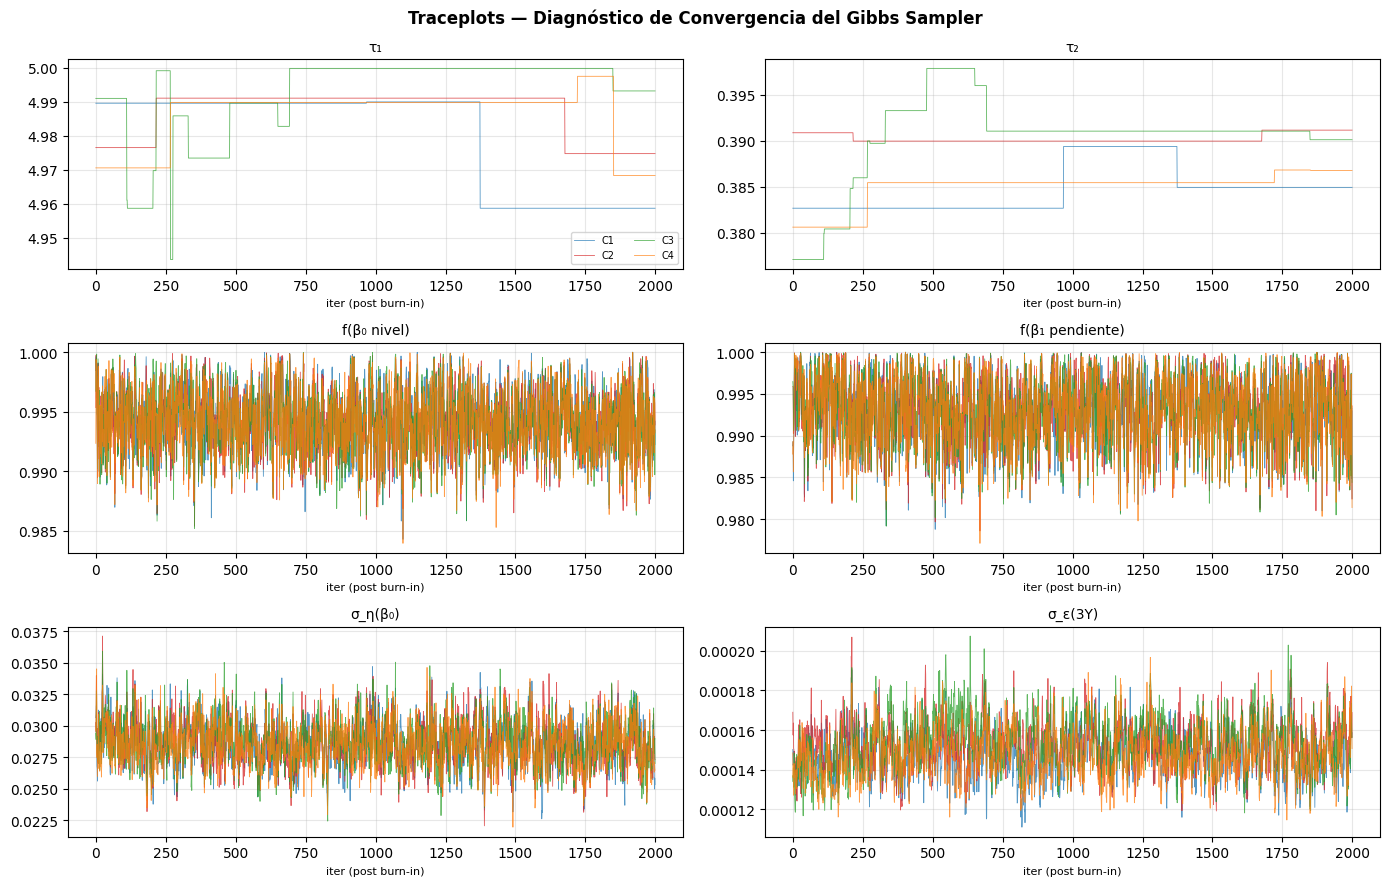

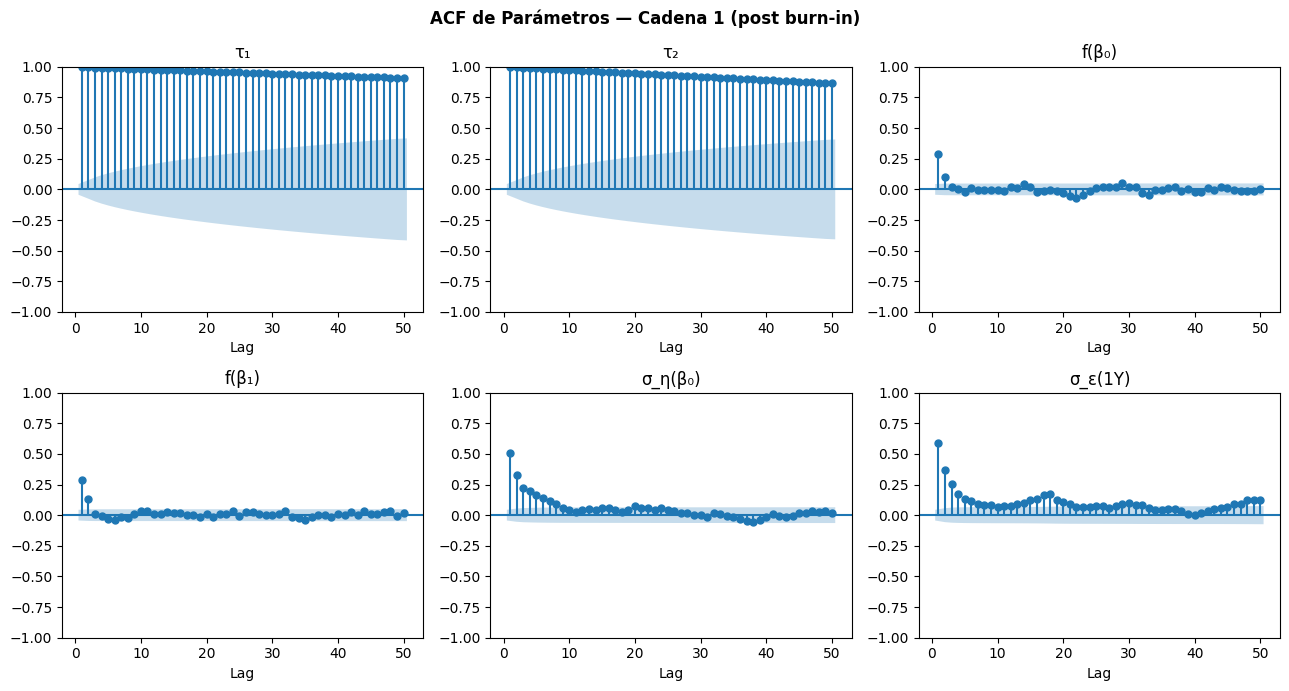


── Resumen de la Distribución Posterior ─────────────────────────
         Parámetro   Media    Std  IC 2.5%  IC 97.5%
       μ(β₀ Nivel)  4.7285 1.4918   1.0798    6.9849
   μ(β₁ Pendiente) -2.8592 2.2249  -7.2638    2.3696
   μ(β₂ Curvatura)  0.5982 1.3487  -2.3840    3.0593
  μ(β₃ Curvatura2)  1.3861 1.4866  -1.6598    4.3676
       f(β₀ Nivel)  0.9942 0.0026   0.9890    0.9990
   f(β₁ Pendiente)  0.9931 0.0040   0.9846    0.9996
   f(β₂ Curvatura)  0.9835 0.0065   0.9711    0.9961
  f(β₃ Curvatura2)  0.9832 0.0063   0.9706    0.9952
     σ_η(β₀ Nivel)  0.1690 0.0052   0.1589    0.1793
 σ_η(β₁ Pendiente)  0.3083 0.0080   0.2927    0.3242
 σ_η(β₂ Curvatura)  0.5131 0.0149   0.4848    0.5424
σ_η(β₃ Curvatura2)  0.6174 0.0198   0.5794    0.6582
           σ_ε(1Y)  6.8222 0.2543   6.3377    7.3328
           σ_ε(2Y)  1.2858 0.0595   1.1710    1.4041
           σ_ε(3Y)  1.2236 0.0517   1.1263    1.3274
           σ_ε(5Y)  1.8059 0.0605   1.6917    1.9275
           σ_ε(7Y)  1.1737 0.049

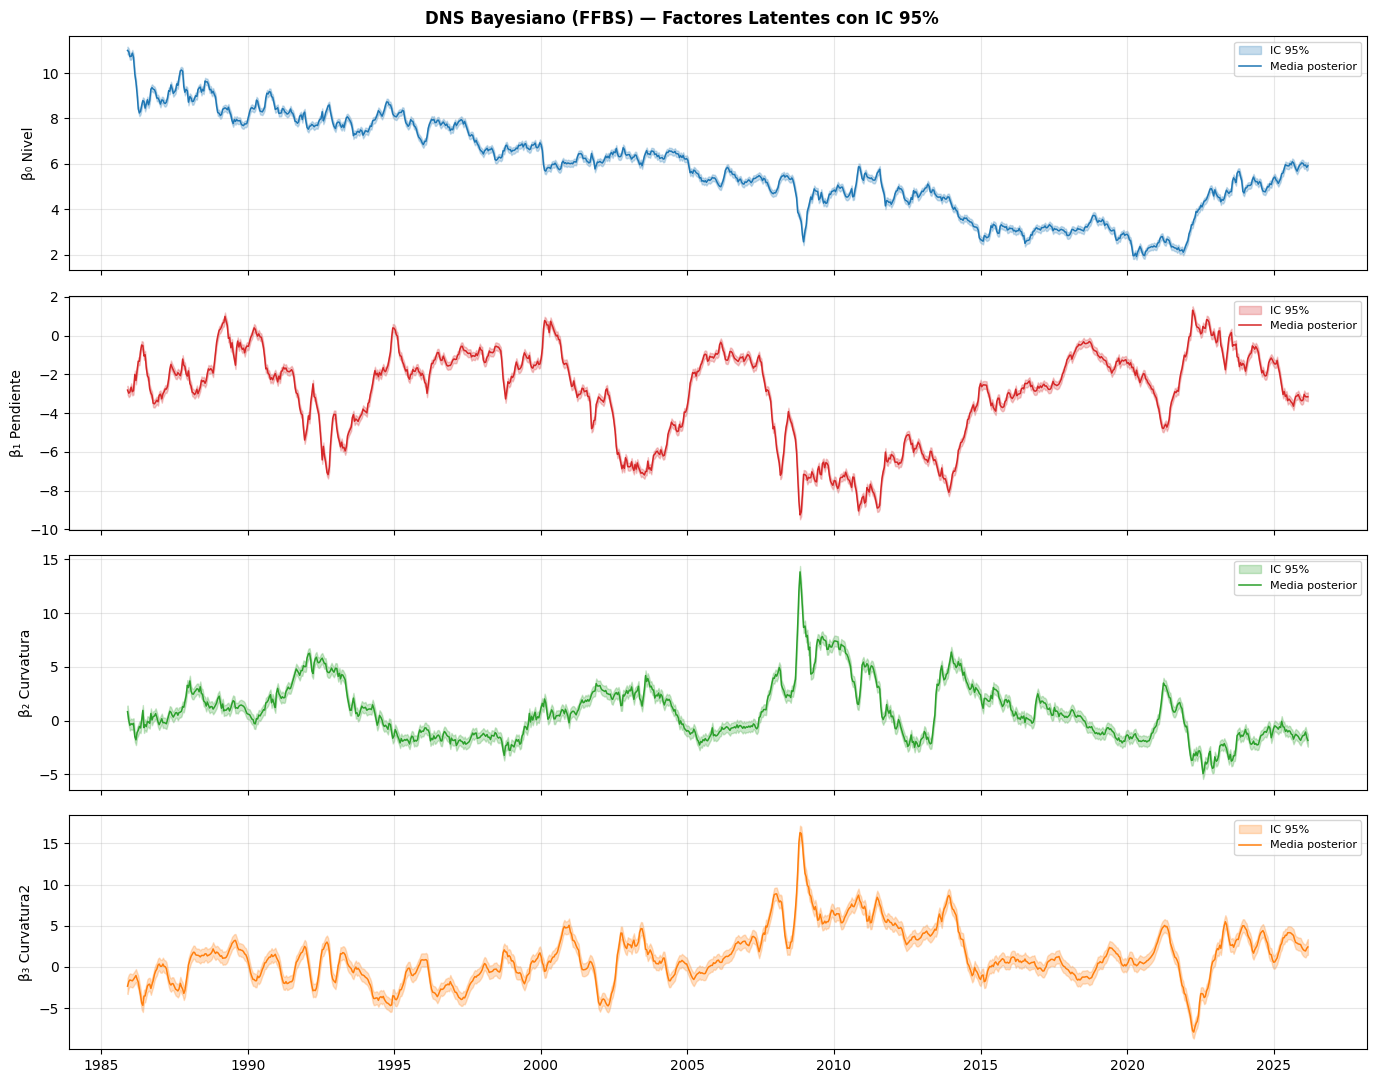

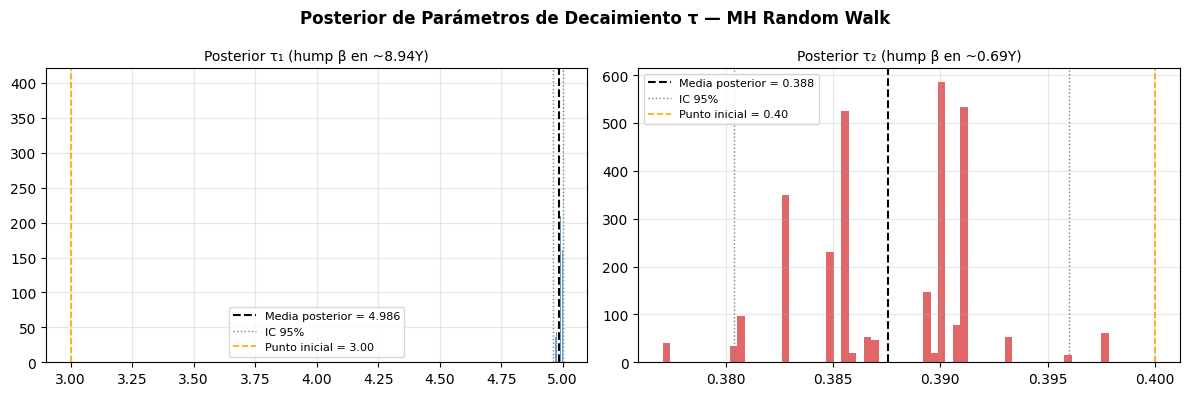


⚠ No se encontró archivo KF — ejecutar primero DNSS_KalmanFilter_Optimizado.ipynb

── Ajuste en muestra (τ₁=4.99, τ₂=0.39) ──────────────
Plazo  RMSE(pb)  MAE(pb)  Sesgo(pb)  JB p-val
────────────────────────────────────────────────
    1Y :    6.22pb    4.83pb     -1.34pb     0.008 ← no normal
    2Y :    0.55pb    0.41pb      0.02pb     0.000 ← no normal
    3Y :    0.76pb    0.56pb      0.21pb     0.000 ← no normal
    5Y :    1.54pb    1.13pb     -0.63pb     0.000 ← no normal
    7Y :    0.49pb    0.34pb     -0.01pb     0.000 ← no normal
   10Y :    4.47pb    3.37pb      2.16pb     0.000 ← no normal
   20Y :    1.84pb    1.37pb      0.04pb     0.000 ← no normal
   30Y :   28.82pb   23.17pb    -16.76pb     0.088
────────────────────────────────────────────────
  TOTAL  :   10.58pb


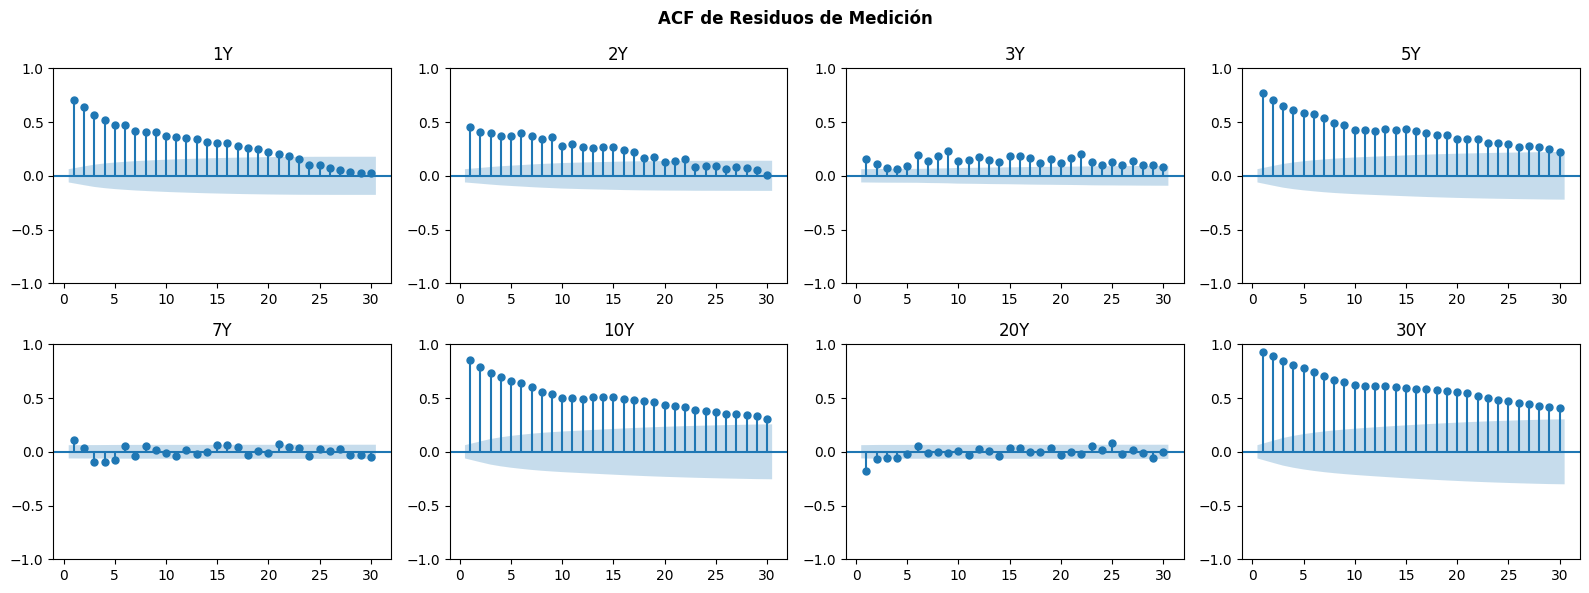

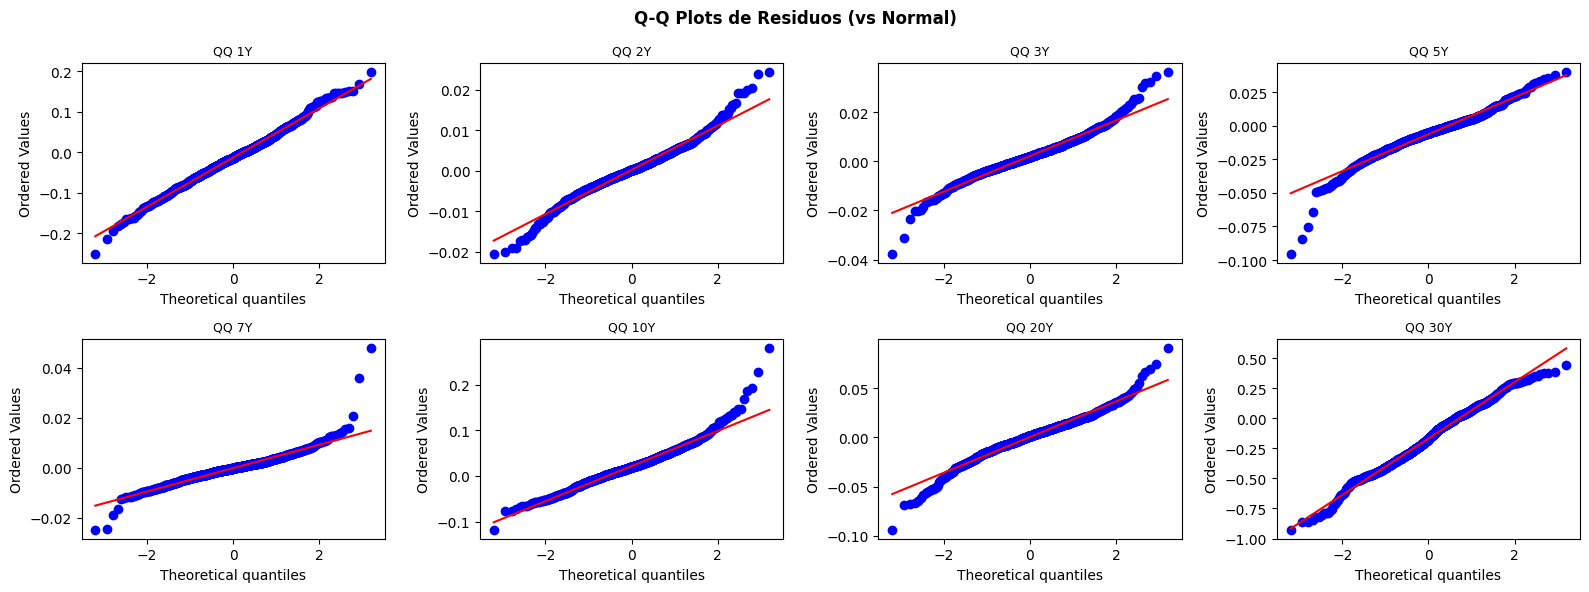

In [22]:
if __name__ == '__main__':

    # ── Correr MCMC ───────────────────────────────────────────────────────────
    chains = run_mcmc(
        n_iter   = 3000,
        n_burnin = 1000,
        n_chains = 4,
        tau_prop_std = np.array([0.03, 0.02])
    )

    # ── Diagnósticos ──────────────────────────────────────────────────────────
    diag_df = compute_diagnostics(chains)
    print("\n── Diagnósticos de Convergencia ────────────────────────────────")
    print(diag_df.to_string(index=False))

    all_converged = (diag_df['R̂'] < 1.10).all()
    print(f"\n{'✓ Todos los parámetros convergieron (R̂<1.10)' if all_converged else '⚠ Algunos parámetros no convergieron — extender iteraciones'}")

    plot_traceplots(chains)
    plot_acf_params(chains, n_chain=0)

    # ── Resumen posterior ─────────────────────────────────────────────────────
    summary_df = posterior_summary(chains)
    print("\n── Resumen de la Distribución Posterior ─────────────────────────")
    print(summary_df.to_string(index=False))

    # ── Factores ──────────────────────────────────────────────────────────────
    df_post, all_betas = extract_posterior_factors(chains)
    plot_posterior_factors(df_post)
    plot_tau_posterior(chains)

    # ── Comparación vs KF ─────────────────────────────────────────────────────
    for kf_file in ['dnss_betas_fixed.csv', 'dnss_betas_tv.csv']:
        try:
            df_kf = pd.read_csv(kf_file)
            print(f"\nComparando con KF: {kf_file}")
            plot_comparison_kf(df_post, df_kf)
            break
        except FileNotFoundError:
            continue
    else:
        print("\n⚠ No se encontró archivo KF — ejecutar primero DNSS_KalmanFilter_Optimizado.ipynb")

    # ── Residuos ──────────────────────────────────────────────────────────────
    resid, fitted = residual_analysis(df_post, chains)

    # ── Exportar ──────────────────────────────────────────────────────────────
    #export_results(df_post, chains, summary_df, diag_df)